# Grundläggande analys och statistik

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
from scipy import stats
from statsmodels.stats.power import TTestIndPower

In [2]:
class HealthAnalyzer:

    # Loading and summerizing

    def __init__(self, csv_path: str):
        """
        Loading the .csv file into a DataFrame from given path.
        """
        self.df: pd.DataFrame = pd.read_csv(csv_path)
    
    def describe(self):
        """
        Display statistics rounded by 2 decimals.
        """
        display(self.df.describe().round(2))

    def info(self):
        """
        Display info about the data: columns, missing values, Dtype
        """
        self.df.info()
    
    def summary(self):
        """
        Displays a summary of mean, median, min and max for: age, weight, systolic blood pressure, cholesterol.
        """
        data_summary =  (self.df[["age", "weight", "height", "systolic_bp", "cholesterol"]]
                 .agg(["mean", "median", "min", "max"])
                 .round(2)
                 )
        display(data_summary)

    # Visualizations

    def weight_per_sex_viz(self):
        """
        Displays a boxplot of weight per sex
        """
        fig, ax = plt.subplots(figsize=(8,5))
        ax.boxplot([self.df.loc[self.df["sex"] == "M", "weight"], 
            self.df.loc[self.df["sex"] == "F", "weight"]], 
            tick_labels=["Male", "Female"]
            )
        ax.set_xlabel("Sex")
        ax.set_ylabel("Weight")
        ax.set_title("Weight per sex")
        plt.tight_layout()
        plt.show()
    
    def bp_amount_viz(self, bins: int= 25):
        """
        Displays a histogram of amount of people by blood pressure, number of bins by default is 25.\n
        bins : number of bins, 25 by default.
        """
        fig, ax = plt.subplots(figsize=(8, 5))

        ax.hist(self.df["systolic_bp"].dropna(), bins = bins, edgecolor="black")
        ax.set_title("Amount of people with a certain blood pressure")
        ax.set_xlabel("Blood pressure")
        ax.set_ylabel("Amount of people")
        ax.grid(True, axis="y")
        plt.tight_layout()
        plt.show()
    
    def bp_by_smoker_viz(self):
        """
        Displays a violin plot of systolic blood pressure by smokers/non-smokers.
        """
        fig, ax = plt.subplots(figsize=(8,5))
        ax.violinplot([self.df.loc[self.df["smoker"] == "Yes", "systolic_bp"], 
               self.df.loc[self.df["smoker"] == "No", "systolic_bp"]], 
               showmeans=True, showmedians=True
               )
        ax.set_title("Violin plot of systolic blood pressure by smoker/non-smoker")
        ax.set_xlabel("Group")
        ax.set_xticks([1, 2])
        ax.set_xticklabels(["Smoker", "Non-smoker"])
        ax.set_ylabel("Blood pressure")
        ax.grid(True, axis="y", alpha=0.5)
        plt.tight_layout()
        plt.show()
    
    # Compare

    def compare_disease(self, n = 1000):
        """
        Displays observed % of people with the disease, and compares it to a randomized simulation using the same % as observed.\n
        n : size of simulated population, 1000 by default.
        """
        
        disease_amount = self.df["disease"].mean()
        np.random.seed(42)

        disease_simulated = np.random.choice([1, 0], p=[disease_amount, 1-disease_amount], size=n)
        disease_simulated_percentage = disease_simulated.mean()

        print(f"{disease_amount*100:.3f}% of the people in the health study has the disease.")
        print(f"Randomized number of disease per {n} people with the same percentage as observed({disease_amount*100:.3f}%) gives {disease_simulated_percentage*100:.3f}%.")

        # Compare results.
        if disease_simulated_percentage > disease_amount:
            print(f"Simulated percentage is {(disease_simulated_percentage - disease_amount)*100:.3f}% larger than observed.")
        elif disease_simulated_percentage < disease_amount:
            print(f"Simulated percentage is {abs(disease_simulated_percentage - disease_amount)*100:.3f}% smaller than observed.")
        else:
            print("There is no difference between the simulated and observed percentage.")

    # Statistical tests.

    def welch_t_test(self):
        """
        Calculates and displays the p-value and t-stat of the data to see if the average value of blood pressure between smokers and non-smokers truly differ.
        """
        smokers_bp = self.df[self.df["smoker"] == "Yes"]["systolic_bp"]
        nonsmokers_bp = self.df[self.df["smoker"] == "No"]["systolic_bp"]

        t_stat, p_val = stats.ttest_ind(smokers_bp, nonsmokers_bp, equal_var=False)

        print(f"Mean for smokers: {smokers_bp.mean():.3f}")
        print(f"Mean for non-smokers: {nonsmokers_bp.mean():.3f}")
        print(f"Standard t-test: t = {t_stat:.3f}, p = {p_val:.3f}")
    
    def normal_approx_method(self):
        """
        Confidence interval using the normal approximation method, displays mean, standard deviation, standard error and 95% CI.
        """
        # Confidence interval using the normal approximation method.
        n = len(self.df["systolic_bp"])
        s = self.df["systolic_bp"].std(ddof=1)
        mean_x = self.df["systolic_bp"].mean()
        z = 1.96
        se = s / np.sqrt(n)

        low = mean_x - z * se
        high = mean_x + z * se

        print(f"Mean: {mean_x:.2f}")
        print(f"Standard deviation: {s:.2f}")
        print(f"Standard error: {se:.2f}\n")
        print(f"Normal approximation 95% CI: {low:.2f}, {high:.2f}")

    def bootstrap_method(self, B: int= 10000, confidence: float= 0.95):
        """
        Bootstrap method for confidence interval for mean systolic blood pressure, 95% by default. Compares results with normal approximation method.\n
        B : Number of resamples (10 000 by default)
        confidence : 95% by default
        """
        z = 1.96
        np.random.seed(42)
        boot_x = self.df["systolic_bp"]
        boot_n = len(boot_x)
        boot_means = np.empty(B)
        mean_x = self.df["systolic_bp"].mean()

        s = self.df["systolic_bp"].std(ddof=1)
        n = len(self.df["systolic_bp"])
        se = s / np.sqrt(n)

        low = mean_x - z * se
        high = mean_x + z * se

        for b in range(B):
            boot_sample = np.random.choice(boot_x, size=boot_n, replace=True)
            boot_means[b] = np.mean(boot_sample)

        alpha = (1 - confidence) / 2
        boot_lo, boot_hi = np.percentile(boot_means, [100*alpha, 100*(1-alpha)])

        print(f"Bootstrap 95% CI: {boot_lo:.2f}, {boot_hi:.2f}")
        print(f"\nDifference in CI between the two methods: lower={(boot_lo - low):.3f}, upper = {(boot_hi - high):.3f}\n")

    def power_t_test(self, alpha: float=0.05, power: float=0.8):
        """
        Tests the power of our t-test by calculating the statistical power and size needed to achieve 80%(default) power.\n
        alpha : 5% default, acceptable risk of false-positive
        power : 80% by default, needed for test to detect any statistically significant effects.
        """
        smokers_bp = self.df[self.df["smoker"] == "Yes"]["systolic_bp"]
        nonsmokers_bp = self.df[self.df["smoker"] == "No"]["systolic_bp"]
        mean_smokers = smokers_bp.mean()
        mean_non = nonsmokers_bp.mean()
        n_smokers = len(smokers_bp)
        n_non = len(nonsmokers_bp)

        sd_pooled = np.sqrt(((n_smokers -1) * smokers_bp.std(ddof=1) ** 2 + (n_non - 1)*nonsmokers_bp.std(ddof=1)**2) / (n_smokers + n_non -2))

        cohen_d = (mean_smokers - mean_non) / sd_pooled

        ratio = n_smokers / n_non

        power_T = TTestIndPower().power(
            effect_size=cohen_d,
            nobs1=n_non,
            alpha=alpha,
            ratio=ratio,
            alternative="larger"
        )

        n_needed_T = TTestIndPower().solve_power(
            effect_size=cohen_d,
            alpha=alpha,
            power=power,
            ratio=ratio,
            alternative="larger"
        )

        print(f"Power for the test to detect a difference: {power_T*100:.2f}%")
        print(f"Sample size needed to reach a power of {power*100:.2f}%: {n_needed_T:.0f} -- compared to the observed sample size of {len(self.df["smoker"])} people.")

data_set = HealthAnalyzer("data/health_study_dataset.csv")


In [14]:
data_set.describe()
data_set.info()

,id,age,height,weight,systolic_bp,cholesterol,disease
count,800.00,800.00,800.00,800.00,800.00,800.00,800.00
mean,400.50,49.43,171.85,73.41,149.18,4.93,0.06
std,231.08,14.50,9.80,13.69,12.79,0.85,0.24
min,1.00,18.00,144.40,33.70,106.80,2.50,0.00
25%,200.75,39.00,164.78,64.80,140.90,4.33,0.00
50%,400.50,50.00,171.35,73.20,149.40,4.97,0.00
75%,600.25,59.00,178.92,82.60,157.60,5.48,0.00
max,800.00,90.00,200.40,114.40,185.90,7.88,1.00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           800 non-null    int64  
 1   age          800 non-null    int64  
 2   sex          800 non-null    object 
 3   height       800 non-null    float64
 4   weight       800 non-null    float64
 5   systolic_bp  800 non-null    float64
 6   cholesterol  800 non-null    float64
 7   smoker       800 non-null    object 
 8   disease      800 non-null    int64  
dtypes: float64(4), int64(3), object(2)
memory usage: 56.4+ KB


**Mean, median, min och max for: age, weight, height, systolic blood pressure, cholesterol**

In [4]:
data_set.summary()

,age,weight,height,systolic_bp,cholesterol
mean,49.43,73.41,171.85,149.18,4.93
median,50.00,73.20,171.35,149.40,4.97
min,18.00,33.70,144.40,106.80,2.50
max,90.00,114.40,200.40,185.90,7.88


**Visualization**

Displays a boxplot of weight per sex, a histogram showing amount of people per blood pressure and lastly a violin plot of blood pressure by smoker/nonsmoker.

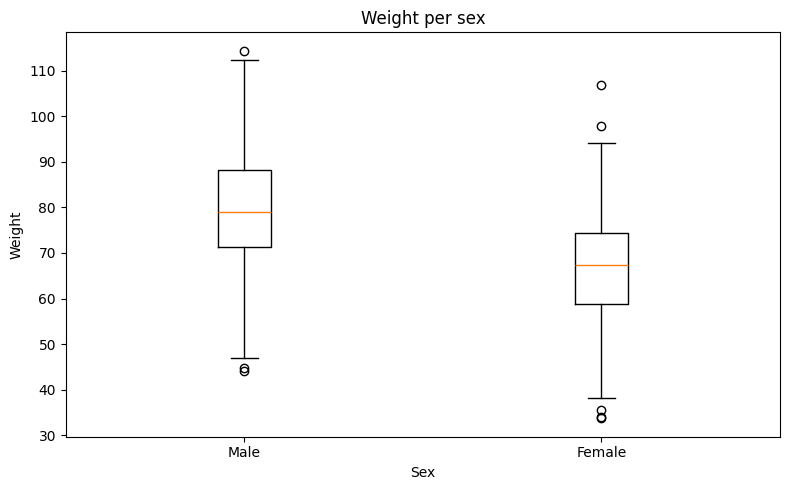

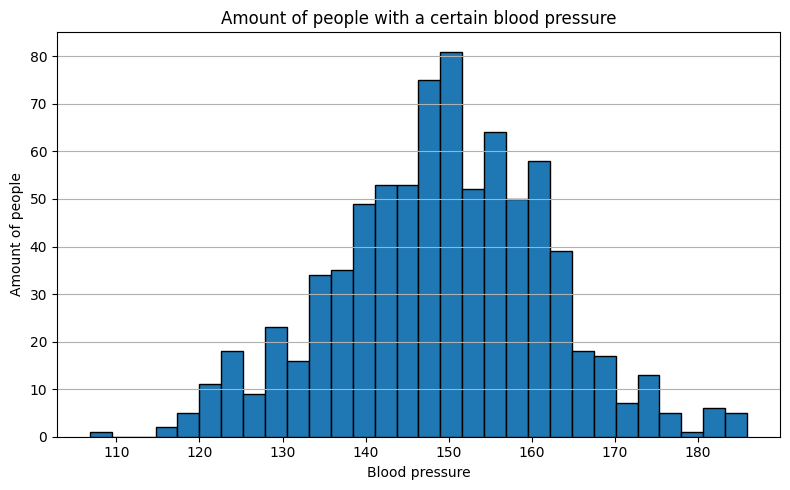

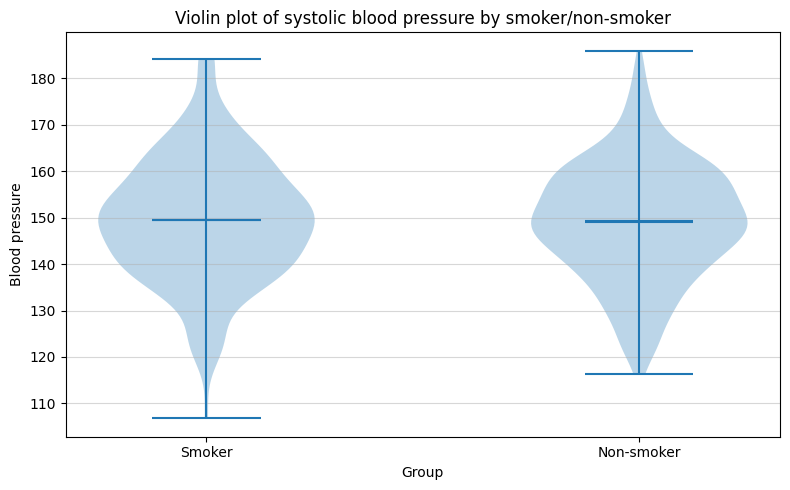

In [5]:
data_set.weight_per_sex_viz()
data_set.bp_amount_viz(bins = 30)
data_set.bp_by_smoker_viz()

When looking at weight, we see a clear distinction between males and females where males on average weigh more. The systolic blood pressure centers around 150 mmHg and the histogram shows how the spread is similar on both sides of the mean(149 mmHg). The violin plot looks similar for both smokers and non-smokers, where the horisontal line represents the mean, and the graph alone can't give us any clear differences.

**Compares observed results with a simulated group of equal shares.**

In [6]:
data_set.compare_disease()

5.875% of the people in the health study has the disease.
Randomized number of disease per 1000 people with the same percentage as observed(5.875%) gives 6.300%.
Simulated percentage is 0.425% larger than observed.


**Confidence interval of mean of systolic blood pressure. Using both normal approximation and bootstrap method.**

In [7]:
data_set.normal_approx_method()
data_set.bootstrap_method()

Mean: 149.18
Standard deviation: 12.79
Standard error: 0.45

Normal approximation 95% CI: 148.29, 150.07
Bootstrap 95% CI: 148.30, 150.07

Difference in CI between the two methods: lower=0.005, upper = 0.008



Comparing these two methods, normal approximation and bootstrap, shows similar results regarding CI-values. This tells us that normal approximation is sufficient for this study. Bootstrap is generally more reliable with smaller samples and does not rely on assumptions about the data, it can improve accuracy through resampling. However, seeing the results are almost identical, they both produce values that are reliable for this study, but using both strengthens the result.

External source: https://www.geeksforgeeks.org/maths/bootstrap-method/

**Hypothesis test: smokers have higher mean blood pressure than non-smokers.**

For the test I've chosen to use a Welch t-test. The reasons being that we compare two groups of unequal sample size, but with sufficiently large sample sizes to not need a bootstrap test. 

In [8]:
data_set.welch_t_test()

Mean for smokers: 149.525
Mean for non-smokers: 149.053
Standard t-test: t = 0.450, p = 0.653


A welch t-test value of 0.45 is a value close to 0, which indicates there's no reliable statistical difference between the groups. Paired with a large p-value of 0.645, which means 65.3% of the time a random sample would produce a difference this big or bigger if there were no differences between groups. The welch t-test shows no statistically significant difference between smokers and non-smokers when it comes to systolic blood pressure.

External source: https://www.geeksforgeeks.org/r-language/running-two-sample-t-test-with-unequal-sample-size-in-r/

**Testing the power of my t-test.**

In [9]:
data_set.power_t_test()

Power for the test to detect a difference: 11.81%
Sample size needed to reach a power of 80.00%: 17084 -- compared to the observed sample size of 800 people.


Based on these results, the chance to detect a real difference is very low with the sample size we have. We would need a much larger sample size to be able to achieve the statistical power of 80% and be able to apply any statistical certainty to our results. With this data and all results in mind(normal aprox, bootstrap, welch t-test and power), there is no support for there being a significant difference between smokers and non-smokers regarding their systolic blood pressure.


Alexander Ahl

**Del 2**

In [10]:
from sklearn.linear_model import LinearRegression

**Linear regression**

First I've chosen to do a simple linear regression for age and systolic blood pressure to examine the relasionship between the two. I've used the regression structure from our lectures. To display the results I've chosen two different scatter plots. First one plots each individual's blood pressure and age to see how they relate, together with a regression line that shows the best summary of all values. The slope of the line is determined by the amount of mmHg an individuals systolic blood pressure changes by each year of age.

Secondly I've chosen a residual plot to determine the validity of the linear regression. Our regression line is now the baseline of 0, and it will display the values around it based on how much they differ from our predicted value.


Regression: systolic blood pressure = a + b * age
Intercept(a)        : 122.685 mmHg
Slope(b)            : 0.536 mmHg/year
R²                  : 0.369
Interpretation      : +10 years => +5.36 mmHg systolic blood pressure.



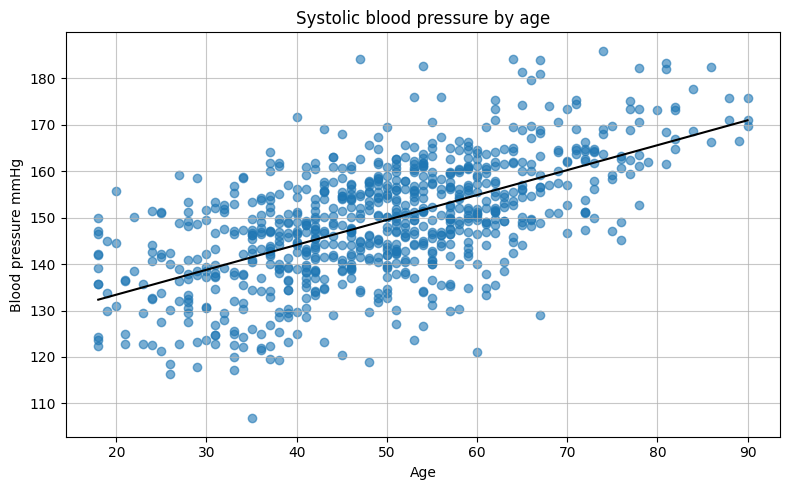

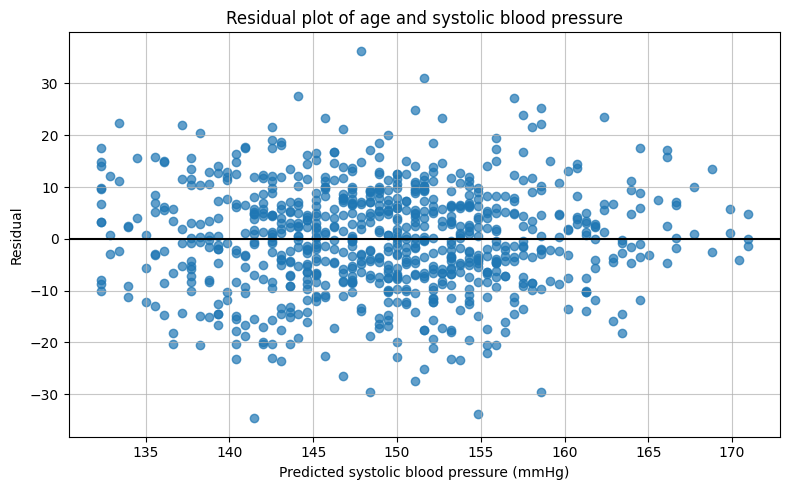

In [11]:
X = data_set.df[["age"]].to_numpy()
y = data_set.df["systolic_bp"].to_numpy()

model = LinearRegression()
model.fit(X, y)

int_hat = float(model.intercept_)
slope_hat = float(model.coef_[0])
y_hat = model.predict(X)
residuals = y - y_hat

ss_tot = np.sum((y - y.mean())**2)
ss_res = np.sum((residuals)**2)
r2 = 1 - ss_res / ss_tot

print(f"""
{"="*60}
Regression: systolic blood pressure = a + b * age
{"="*60}
Intercept(a)        : {int_hat:.3f} mmHg
Slope(b)            : {slope_hat:.3f} mmHg/year
R²                  : {r2:.3f}
Interpretation      : +10 years => +{10*slope_hat:.2f} mmHg systolic blood pressure.
""")

plt.figure(figsize=(8,5))
plt.scatter(X[:,0], y, alpha=0.6)
x_line = np.linspace(X.min(), X.max(), 100)
y_line = int_hat + slope_hat * x_line
plt.plot(x_line, y_line, color="black")
plt.xlabel("Age")
plt.ylabel("Blood pressure mmHg")
plt.title("Systolic blood pressure by age")
plt.grid(True, alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(y_hat, residuals, alpha=0.7)
plt.axhline(0, color="black")
plt.title("Residual plot of age and systolic blood pressure")
plt.xlabel("Predicted systolic blood pressure (mmHg)")
plt.ylabel("Residual")
plt.grid(True, alpha=0.7)
plt.tight_layout()
plt.show()


Our single linear regression found that systolic blood pressure increases by 0.536 mmHg/year. Age explains 36.9% of the variance. Our residual plot gives support to our regression line, with values beeing equally spread across the span of blood pressure, and most values beeing centered near the baseline. Only a few individuals differ greater than +-20 from the predicted line.

**BMI**

To complement our data I've chosen to add a column in our dataframe based on BMI, where weight is better represented in terms of being over- and underweight, and therefor how weight relates to blood pressure. A tall person can weight more than a short person, and the weight alone doesn't describe wether the person is overweight or not. BMI gives us this data and will more accurately determine if bodyweight relates to systolic blood pressure. BMI is calculated as weight(kg) devided by height(m)^2.

I've chosen to present the results in a scatter plot to visualize the relation between the two. I've also added discription of the data to see how they relate in numbers.

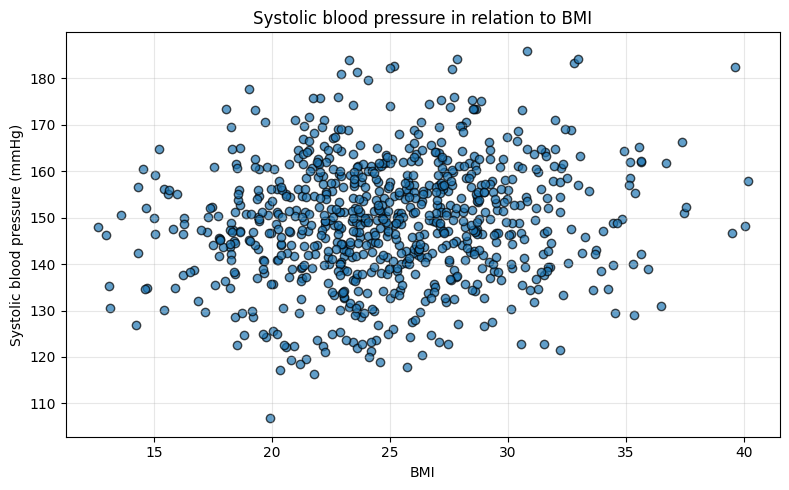

,bmi,systolic_bp
count,800.000000,800.000000
mean,24.933722,149.178625
std,4.661261,12.793360
min,12.634903,106.800000
25%,21.918637,140.900000
50%,24.703622,149.400000
75%,28.011842,157.600000
max,40.141267,185.900000


In [15]:
data_set_copy = data_set.df.copy()                                                                      # We add BMI as a column to a copy of our original data.
data_set_copy["bmi"] = data_set_copy["weight"] / ((data_set_copy["height"] / 100) ** 2)                 # height is a value of cm, so we convert to m first.

plt.figure(figsize=(8, 5))
plt.scatter(data_set_copy["bmi"], data_set_copy["systolic_bp"], alpha=0.7, edgecolors="black")
plt.title("Systolic blood pressure in relation to BMI")
plt.xlabel("BMI")
plt.ylabel("Systolic blood pressure (mmHg)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(data_set_copy[["bmi", "systolic_bp"]].describe())

As we can see by both the scatter plot and the data systolic blood pressure increases as BMI goes up. The majority of subjects centeres around 25 BMI and 149 mmHg, the top 25% of BMI has an average of 157.6 mmHg whilst the bottom 25% of BMI has an average of 140.9 mmHg.

**Multiple linear regression**

For our last analysis I've chosen to expand our simple linear regression to a multiple. The multiple linear regression looks at the relation between blood pressure and age, BMI, sex and smoking habbits, and present the data in numerical only to avoid a visualization with too many variables, for easier interpretation and readability. I've used get_dummies in pandas to turn categorical variables into 0/1 for use in LinearRegression.

https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html

In [16]:
X1 = data_set_copy[["age", "sex", "bmi", "smoker"]]
y1 = data_set_copy["systolic_bp"]

X1 = pd.get_dummies(X1, drop_first=True)
X1 = X1.to_numpy()


model_m = LinearRegression()
model_m.fit(X1, y1)

int_bp = float(model_m.intercept_)
slope_age = float(model_m.coef_[0])
slope_bmi = float(model_m.coef_[1])
slope_sex = float(model_m.coef_[2])
slope_smoker = float(model_m.coef_[3])

r2_m = model_m.score(X1, y1)

print(f"""
{"="*85}
Multiple regression: systolic blood pressure (age + sex + BMI + smoking habbits)
{"="*85}
Intercept               : {int_bp:.3f} mmHg
Age                     : {slope_age:.3f} mmHg/year
BMI                     : {slope_bmi:.3f} mmHg/unit
Sex difference(M/F)     : {slope_sex:.3f} mmHg
Smoker(Y/N)             : {slope_smoker:.3f} mmHg
R²                      : {r2_m:.3f}
Interpretation          : +10 years => +{10*slope_age:.2f} mmHg systolic blood pressure.
                        : +1 BMI => +{slope_bmi:.2f} mmHg.
                        : Males have {slope_sex:.2f} mmHg higher BP than females.
                        : Smokers have {slope_smoker:.2f} mmHg lower BP than non-smokers.
""")



Multiple regression: systolic blood pressure (age + sex + BMI + smoking habbits)
Intercept               : 112.231 mmHg
Age                     : 0.540 mmHg/year
BMI                     : 0.365 mmHg/unit
Sex difference(M/F)     : 2.468 mmHg
Smoker(Y/N)             : -0.304 mmHg
R²                      : 0.397
Interpretation          : +10 years => +5.40 mmHg systolic blood pressure.
                        : +1 BMI => +0.36 mmHg.
                        : Males have 2.47 mmHg higher BP than females.
                        : Smokers have -0.30 mmHg lower BP than non-smokers.



Our multiple regression model found that systolic blood pressure increases by 0.54 mmHg/year when accounting for sex, BMI and smoking habbits. A slight increase from the linear regression(0.536mmHg/year). It also shows that BP increases by 0.37 mmHg per BMI unit, and that males have 2.47 mmHg higher BP on average. It also tells us smokers have -0.3 mmHg lower BP than non-smokers. This model explains 39.7% of the variance, compared to 36.9% of the single linear regression(age only).

In conclusion, our statistical analysis of systolic blood pressure doesn't support the hypothesis that smokers have higher BP than non-smokers.